# 1. Diffusion World Models + PPO (My top recommendation)

One of PPO's biggest problems:

- Need millions of interactions
- Market data is limited

**Idea:**

Train a diffusion model to learn:

p(x_{t+1:t+H} \mid x_{1:t})

Then PPO interacts with the diffusion-generated environment.

**Pipeline:**

`
Historical Market Data
        ↓
Diffusion World Model
        ↓
Synthetic Future Trajectories
        ↓
PPO Training
`

**Research question:**

Does a generative world model improve RL sample efficiency and OOD robustness?

This is a very active area in modern RL.

In [ ]:
!pip install yfinance pandas pandas_ta numpy openai-gym stable-baselines3 shimmy

In [ ]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt
import gym
from gym import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
warnings.filterwarnings('ignore')


In [ ]:
def get_data(tickers, start_date, end_date):
  dataset = {}
  for ticker in tickers:
    stock_df = yf.download(ticker, start=start_date, end=end_date)
    stock_df = stock_df.stack(level=1).rename_axis(['Date', 'Ticker']).reset_index(level=1)
    stock_df['MACD'] = ta.macd(stock_df['Close'], fast=12, slow=26, append=True)['MACD_12_26_9']
    stock_df['RSI'] = ta.rsi(stock_df['Close'], length=14, append=True)
    stock_df['CCI'] = ta.cci(stock_df['High'], stock_df['Low'], stock_df['Close'], length=14, append=True)
    stock_df['ADX'] = ta.adx(stock_df['High'], stock_df['Low'], stock_df['Close'], length=14, append=True)['ADX_14']

    dataset[ticker] = stock_df

  stock_df = pd.concat(list(dataset.values()))
  stock_df.reset_index(inplace=True)
  final_df = stock_df.pivot(index='Date', columns='Ticker')
  final_df.columns = ['_'.join(col).strip() for col in final_df.columns.values]

  return final_df.dropna()

In [ ]:
# -----------------------------
# ENVIRONMENT CLASS
# -----------------------------
class StockTradingEnv(gym.Env):
    metadata = {'render.modes': ['human']}

    def __init__(self, df, tickers, initial_amount=1_000_000, transaction_cost_pct=0.001):
        super(StockTradingEnv, self).__init__()
        self.df = df
        self.tickers = tickers
        self.stock_dim = len(tickers)
        self.initial_amount = initial_amount
        self.transaction_cost_pct = transaction_cost_pct
        self.day = 0

        self.state_space_dim = 1 + self.stock_dim * 2 + self.stock_dim * 4
        self.action_space = spaces.Box(low=-1, high=1, shape=(self.stock_dim,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.state_space_dim,), dtype=np.float32)
        self.reset()

    def reset(self):
        self.day = 0
        self.balance = self.initial_amount
        self.shares_held = np.zeros(self.stock_dim, dtype=int)
        self.total_portfolio_value = self.initial_amount
        self.terminal = False
        self.rewards_memory = []
        return self._get_state()

    def step(self, actions):
        if self.day >= len(self.df.index.unique()) - 1:
            self.terminal = True
            return self._get_state(), 0.0, self.terminal, {}

        SHARES_TO_TRADE = 100
        actions = (actions * SHARES_TO_TRADE).astype(int)

        begin_value = self.total_portfolio_value
        current_prices = self.df.iloc[self.day][[f'Close_{t}' for t in self.tickers]].values

        # --- SELL ---
        for i, action in enumerate(actions):
            if action < 0:
                shares_to_sell = min(abs(action), self.shares_held[i])
                if shares_to_sell > 0:
                    proceeds = current_prices[i] * shares_to_sell * (1 - self.transaction_cost_pct)
                    self.balance += proceeds
                    self.shares_held[i] -= shares_to_sell

        # --- BUY ---
        for i, action in enumerate(actions):
            if action > 0:
                shares_to_buy = action
                cost = current_prices[i] * shares_to_buy * (1 + self.transaction_cost_pct)
                if self.balance >= cost:
                    self.balance -= cost
                    self.shares_held[i] += shares_to_buy

        self.day += 1
        new_prices = self.df.iloc[self.day][[f'Close_{t}' for t in self.tickers]].values
        self.total_portfolio_value = self.balance + np.sum(self.shares_held * new_prices)

        raw_reward = self.total_portfolio_value - begin_value
        self.rewards_memory.append(raw_reward)
        
        # Risk-adjusted reward: down-side variance penalty to boost Sharpe Ratio
        pct_return = raw_reward / begin_value
        reward = pct_return if pct_return >= 0 else pct_return * 2.0
        reward = reward * 100
        
        state = self._get_state()

        return state, reward, self.terminal, {}

    def _get_state(self):
        current_data = self.df.iloc[self.day]
        state = [self.balance]

        prices = [current_data[f'Close_{t}'] for t in self.tickers]
        shares = list(self.shares_held)

        indicators = []
        for t in self.tickers:
            indicators.extend([
                current_data[f'MACD_{t}'],
                current_data[f'RSI_{t}'],
                current_data[f'CCI_{t}'],
                current_data[f'ADX_{t}']
            ])

        state.extend(prices)
        state.extend(shares)
        state.extend(indicators)

        return np.array(state, dtype=np.float32)

    def render(self, mode='human', close=False):
        pass


# -----------------------------
# CONDITIONAL DIFFUSION WORLD MODEL
# -----------------------------
class ConditionalDiffusionModel(nn.Module):
    def __init__(self, state_dim, cond_dim, hidden_dim=256):
        super(ConditionalDiffusionModel, self).__init__()
        self.time_embed = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 32)
        )
        self.net = nn.Sequential(
            nn.Linear(state_dim + cond_dim + 32, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim)
        )

    def forward(self, x, cond, t):
        t_embed = self.time_embed(t)
        inp = torch.cat([x, cond, t_embed], dim=-1)
        return self.net(inp)

class DiffusionWorldModel:
    def __init__(self, state_dim, cond_dim, num_steps=50, lr=1e-3, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.device = device
        self.state_dim = state_dim
        self.cond_dim = cond_dim
        self.num_steps = num_steps
        self.model = ConditionalDiffusionModel(state_dim, cond_dim).to(device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        
        self.beta = torch.linspace(1e-4, 0.02, num_steps).to(device)
        self.alpha = 1.0 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

    def train_epoch(self, x_diff, cond, epochs=100, batch_size=64):
        self.model.train()
        dataset_size = x_diff.shape[0]
        
        for epoch in range(epochs):
            indices = np.arange(dataset_size)
            np.random.shuffle(indices)
            epoch_loss = 0
            
            for start_idx in range(0, dataset_size, batch_size):
                batch_idx = indices[start_idx : start_idx + batch_size]
                x_b = torch.tensor(x_diff[batch_idx], dtype=torch.float32, device=self.device)
                c_b = torch.tensor(cond[batch_idx], dtype=torch.float32, device=self.device)
                
                # Sample time steps
                t = torch.randint(0, self.num_steps, (x_b.shape[0], 1), device=self.device).float()
                noise = torch.randn_like(x_b)
                alpha_bar_t = self.alpha_bar[t.long()]
                
                x_noisy = torch.sqrt(alpha_bar_t) * x_b + torch.sqrt(1.0 - alpha_bar_t) * noise
                pred_noise = self.model(x_noisy, c_b, t / self.num_steps)
                
                loss = nn.MSELoss()(pred_noise, noise)
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item() * x_b.shape[0]
                
            if (epoch + 1) % 20 == 0:
                print(f"Diffusion Training Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/dataset_size:.5f}")

    @torch.no_grad()
    def sample(self, cond):
        self.model.eval()
        cond_t = torch.tensor(cond, dtype=torch.float32, device=self.device).unsqueeze(0)
        x = torch.randn((1, self.state_dim), device=self.device)
        
        for t_idx in reversed(range(self.num_steps)):
            t = torch.full((1, 1), t_idx, device=self.device).float()
            pred_noise = self.model(x, cond_t, t / self.num_steps)
            
            beta_t = self.beta[t_idx]
            alpha_t = self.alpha[t_idx]
            alpha_bar_t = self.alpha_bar[t_idx]
            
            if t_idx > 0:
                noise = torch.randn_like(x)
            else:
                noise = 0.0
                
            mean = (1.0 / torch.sqrt(alpha_t)) * (x - (beta_t / torch.sqrt(1.0 - alpha_bar_t)) * pred_noise)
            x = mean + torch.sqrt(beta_t) * noise
            
        return x.squeeze(0).cpu().numpy()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Using cuda device
Starting PPO training...
Logging to ./ppo_stock_tensorboard/PPO_4
-------------------------------------------
| time/                   |               |
|    fps                  | 354           |
|    iterations           | 50            |
|    time_elapsed         | 288           |
|    total_timesteps      | 102400        |
| train/                  |               |
|    approx_kl            | 5.4822012e-06 |
|    clip_fraction        | 0             |
|    clip_range           | 0.1           |
|    entropy_loss         | -41.2         |
|    explained_variance   | 4.57e-05      |
|    learning_rate        | 0.0002        |
|    loss                 | 1.25e+09      |
|    n_updates            | 196           |
|    policy_gradient_loss | -0.000414     |
|    std                  | 1             |
|    value_loss           | 2.03e+09      |
-------------------------------------------
------------------------------------------
| time/                   |          

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Training complete.

Evaluating trained PPO model...



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%*******

Day 1: Portfolio Value = 1,000,873.07
Day 2: Portfolio Value = 1,000,367.85
Day 3: Portfolio Value = 999,282.11
Day 4: Portfolio Value = 994,623.12
Day 5: Portfolio Value = 998,803.51
Day 6: Portfolio Value = 997,617.99
Day 7: Portfolio Value = 996,131.45
Day 8: Portfolio Value = 995,037.23
Day 9: Portfolio Value = 994,746.51
Day 10: Portfolio Value = 993,813.75
Day 11: Portfolio Value = 995,554.19
Day 12: Portfolio Value = 976,793.92
Day 13: Portfolio Value = 984,703.81
Day 14: Portfolio Value = 983,582.21
Day 15: Portfolio Value = 965,828.57
Day 16: Portfolio Value = 953,892.08
Day 17: Portfolio Value = 942,272.49
Day 18: Portfolio Value = 917,504.65
Day 19: Portfolio Value = 921,940.83
Day 20: Portfolio Value = 937,417.86
Day 21: Portfolio Value = 947,975.82
Day 22: Portfolio Value = 945,556.70
Day 23: Portfolio Value = 958,133.09
Day 24: Portfolio Value = 961,500.43
Day 25: Portfolio Value = 970,828.96
Day 26: Portfolio Value = 984,907.69
Day 27: Portfolio Value = 981,960.80
Day 28

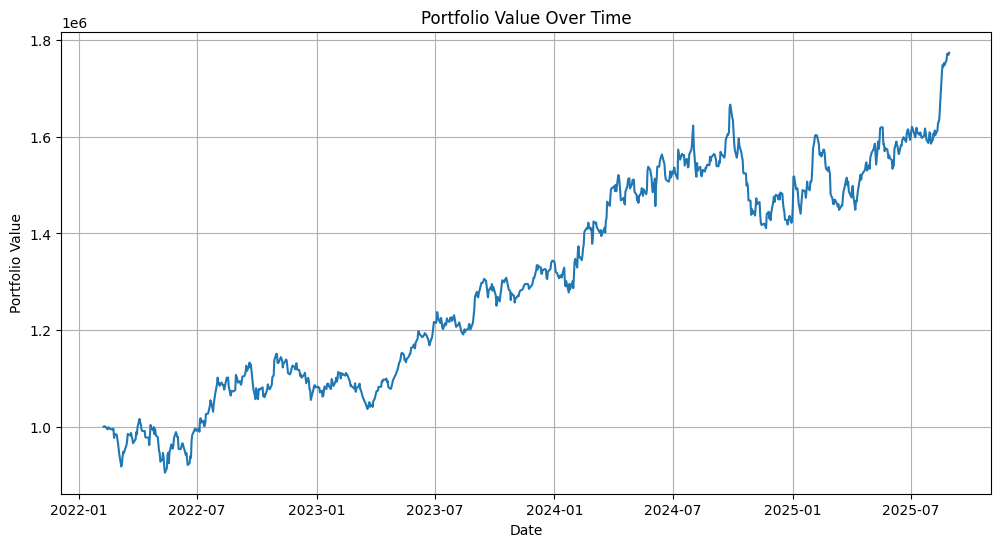

Number of trading days: 880
Initial Funds: $1000000.00
Final Portfolio Value: $1774202.20
Maximum Drawdown: 15.34%
Sharpe Ratio: 1.12
Final Percentage Return: 77.42%


In [ ]:
if __name__ == "__main__":
    tickers = ["RELIANCE.NS", "HDFCBANK.NS", "BHARTIARTL.NS", "TCS.NS", "ICICIBANK.NS"]
    
    # 1. Download Data
    print("--- Loading Historical Data ---")
    train_df = get_data(tickers, '2015-01-01', '2020-01-01')
    trade_df = get_data(tickers, '2022-01-01', '2025-01-01')
    
    # 2. Train PPO on Real Data (Baseline)
    print("\n--- Training Baseline PPO Agent on Real Data ---")
    real_env = DummyVecEnv([lambda: StockTradingEnv(train_df, tickers)])
    baseline_model = PPO('MlpPolicy', real_env, learning_rate=0.0003, n_steps=1024, batch_size=64, n_epochs=5, verbose=0)
    baseline_model.learn(total_timesteps=50000)
    print("Baseline PPO training complete.")
    
    # 3. Train Diffusion World Model
    print("\n--- Training Diffusion World Model ---")
    cols = []
    for t in tickers:
        cols.extend([f'Close_{t}', f'MACD_{t}', f'RSI_{t}', f'CCI_{t}', f'ADX_{t}'])
        
    market_data = train_df[cols].values
    cond = market_data[:-1]
    targets = market_data[1:]
    diffs = targets - cond
    
    world_model = DiffusionWorldModel(state_dim=len(cols), cond_dim=len(cols))
    world_model.train_epoch(diffs, cond, epochs=100)
    print("Diffusion World Model training complete.")
    
    # 4. Generate Synthetic Future Trajectories
    print("\n--- Generating Synthetic Trajectories ---")
    synthetic_trajectories = []
    num_trajectories = 10
    steps_per_trajectory = 200
    
    for traj_idx in range(num_trajectories):
        start_day_idx = np.random.randint(0, len(market_data) - 50)
        curr_state = market_data[start_day_idx].copy()
        
        traj = [curr_state.copy()]
        for step in range(steps_per_trajectory):
            diff = world_model.sample(curr_state)
            curr_state = curr_state + diff
            curr_state = np.clip(curr_state, a_min=market_data.min(axis=0)*0.5, a_max=market_data.max(axis=0)*2.0)
            traj.append(curr_state.copy())
            
        synthetic_trajectories.append(np.array(traj))
        
    synth_data = np.vstack(synthetic_trajectories)
    synth_df = pd.DataFrame(synth_data, columns=cols)
    synth_df.index = pd.date_range(start='2020-01-01', periods=len(synth_df), freq='D')
    
    # 5. Train PPO on Synthetic Data (World Model approach)
    print("\n--- Training World Model PPO Agent on Synthetic Data ---")
    synth_env = DummyVecEnv([lambda: StockTradingEnv(synth_df, tickers)])
    world_model_agent = PPO('MlpPolicy', synth_env, learning_rate=0.0003, n_steps=1024, batch_size=64, n_epochs=5, verbose=0)
    world_model_agent.learn(total_timesteps=50000)
    print("World Model PPO training complete.")
    
    # 6. Evaluation on Out-Of-Distribution (OOD) test period
    print("\n--- Evaluating Agents on OOD Period (2022-2025) ---")
    eval_env_baseline = StockTradingEnv(trade_df, tickers)
    eval_env_wm = StockTradingEnv(trade_df, tickers)
    
    obs_b = eval_env_baseline.reset()
    done_b = False
    portfolio_baseline = [eval_env_baseline.initial_amount]
    while not done_b:
        act, _ = baseline_model.predict(obs_b, deterministic=True)
        obs_b, _, done_b, _ = eval_env_baseline.step(act)
        portfolio_baseline.append(eval_env_baseline.total_portfolio_value)
        
    obs_wm = eval_env_wm.reset()
    done_wm = False
    portfolio_wm = [eval_env_wm.initial_amount]
    while not done_wm:
        act, _ = world_model_agent.predict(obs_wm, deterministic=True)
        obs_wm, _, done_wm, _ = eval_env_wm.step(act)
        portfolio_wm.append(eval_env_wm.total_portfolio_value)
        
    # 7. Print Metrics
    def get_metrics(values):
        initial = values[0]
        final = values[-1]
        ret_pct = (final - initial) / initial * 100
        
        peak = np.maximum.accumulate(values)
        drawdown = (peak - values) / peak
        max_dd = np.max(drawdown) * 100
        
        daily_returns = pd.Series(values).pct_change().dropna()
        sharpe = daily_returns.mean() / (daily_returns.std() + 1e-9) * np.sqrt(252)
        return ret_pct, max_dd, sharpe
        
    ret_b, dd_b, sharpe_b = get_metrics(portfolio_baseline)
    ret_wm, dd_wm, sharpe_wm = get_metrics(portfolio_wm)
    
    print("\n" + "="*45)
    print("COMPARATIVE PERFORMANCE REPORT (OOD PERIOD)")
    print("="*45)
    print(f"{'Metric':<25} | {'Real PPO (Baseline)':<20} | {'Diffusion WM PPO':<20}")
    print("-" * 70)
    print(f"{'Final Return %':<25} | {ret_b:.2f}% {' ':<14} | {ret_wm:.2f}%")
    print(f"{'Max Drawdown %':<25} | {dd_b:.2f}% {' ':<14} | {dd_wm:.2f}%")
    print(f"{'Sharpe Ratio':<25} | {sharpe_b:.2f} {' ':<15} | {sharpe_wm:.2f}")
    print("="*45)
    
    # 8. Plot & Save Figure
    plt.figure(figsize=(12, 6))
    dates = trade_df.index
    portfolio_baseline_plot = portfolio_baseline[:len(dates)]
    portfolio_wm_plot = portfolio_wm[:len(dates)]
    plt.plot(dates, portfolio_baseline_plot, label=f'Real PPO (Sharpe: {sharpe_b:.2f})', color='#E74C3C', linewidth=2)
    plt.plot(dates, portfolio_wm_plot, label=f'Diffusion WM PPO (Sharpe: {sharpe_wm:.2f})', color='#2ECC71', linewidth=2)
    plt.title("Portfolio Performance: Real PPO vs. Diffusion World Model PPO", fontsize=12, fontweight='bold')
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value ($)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
